# Exploratory Data Analysis of the Pfam Dataset
We start by loading in and inspecting the train set of the random split. 

In [1]:
import pandas as pd
import os 
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

train_folder = "../data/random_split/train"
chunk_names = os.listdir("../data/random_split/train")
df = pd.concat([pd.read_csv(f"{train_folder}/{name}") for name in chunk_names])

In [2]:
df["accession_no"] = [val.split(".")[0][2:] for val in df["family_accession"].values]
df.sort_values(by="accession_no", inplace=True)

In [3]:
df.describe()

,family_id,sequence_name,family_accession,aligned_sequence,sequence,accession_no
count,1086741,1086741,1086741,1086741,1086741,1086741
unique,17929,1086741,17929,1086326,1086315,17929
top,Methyltransf_25,A0A1R3U1E1_9RHIZ/1-197,PF13649.6,GLFRF..SL..........S....D.F...C.N...........K....,GLFRFSLSDFCNKSVNHICGSVDDEANVWHSRLCHINFGLMSRLSS...,13649
freq,3637,1,3637,31,32,3637


From the count field we can see that there are no missing values in the dataset. Interestingly, the number of unique sequences is not the same as the total number of sequences.
## Investigating Duplicates

In [4]:
# assert df["sequence"].duplicated().sum() == 0, "There are duplicated rows."
dup_sequences = df.duplicated(subset=['sequence'],keep=False)
dup_sequences_and_labels = df.duplicated(subset=['sequence','accession_no'], keep=False)
dup_sequences_and_aligned = df.duplicated(subset=['sequence','aligned_sequence'], keep=False)
print(f"Duplicated sequences, {dup_sequences.sum()}")
print(f"Duplicated sequences and labels, {dup_sequences_and_labels.sum()}")
print(f"Duplicated sequences and aligned sequences, {dup_sequences_and_aligned.sum()}")
df[dup_sequences].describe()

Duplicated sequences, 659
Duplicated sequences and labels, 655
Duplicated sequences and aligned sequences, 641


,family_id,sequence_name,family_accession,aligned_sequence,sequence,accession_no
count,659,659,659,659,659,659
unique,65,659,65,244,233,65
top,gag_pre-integrs,R9IG83_9FIRM/531-614,PF13976.6,GLFRF..SL..........S....D.F...C.N...........K....,GLFRFSLSDFCNKSVNHICGSVDDEANVWHSRLCHINFGLMSRLSS...,13976
freq,244,1,244,31,32,244


So there are 4 duplicated sequences with different labels, and 18 duplicates with different alignments. Lets isolate those. 

In [5]:
df[dup_sequences & ~dup_sequences_and_labels]

,family_id,sequence_name,family_accession,aligned_sequence,sequence,accession_no
5367,Nucleoplasmin,B4HZJ8_DROSE/6-104,PF03066.15,FY.GVTLTAESDSVTWDVD............EDYARGQKLVIKQIL...,FYGVTLTAESDSVTWDVDEDYARGQKLVIKQILLGAEAKENEFNVV...,03066
2690,NPL,NLP_DROME/6-104,PF17800.1,FYGVTLTAES...DS..VT....WD......VD..EDYAR..GQKL...,FYGVTLTAESDSVTWDVDEDYARGQKLVIKQILLGAEAKENEFNVV...,17800
2981,NAD1,ABEC3_MOUSE/245-418,PF18778.1,DPLSEEEFYSQFYNQRVKHLCYY.HRMKPYL.CYQLE..QF........,DPLSEEEFYSQFYNQRVKHLCYYHRMKPYLCYQLEQFNGQAPLKGC...,18778
7400,NAD2,E9QMH1_MOUSE/234-407,PF18782.1,DPLSEEEFYSQFYNQRVKHLCYYHRMKPYLCYQL.EQFN..GQAP....,DPLSEEEFYSQFYNQRVKHLCYYHRMKPYLCYQLEQFNGQAPLKGC...,18782


Somethings gone wrong here ... For the second case, the version numbers are different, so maybe the classification changed. As it's only 2 out of 1 million, lets just drop both of these 2 pairs of duplicates.

In [6]:
df.drop(df[dup_sequences & ~dup_sequences_and_labels].index, inplace=True)

Sequences with the same label but different alignments are not an issue for us as we will being using sequence as the input and accession_no as the label. Let's drop duplicates of these, just keeping one. 

In [7]:
df.drop_duplicates(subset=['sequence'], inplace=True)

## Class Sizes
Now let's investigate the distribution of classes (accession no) in the model.


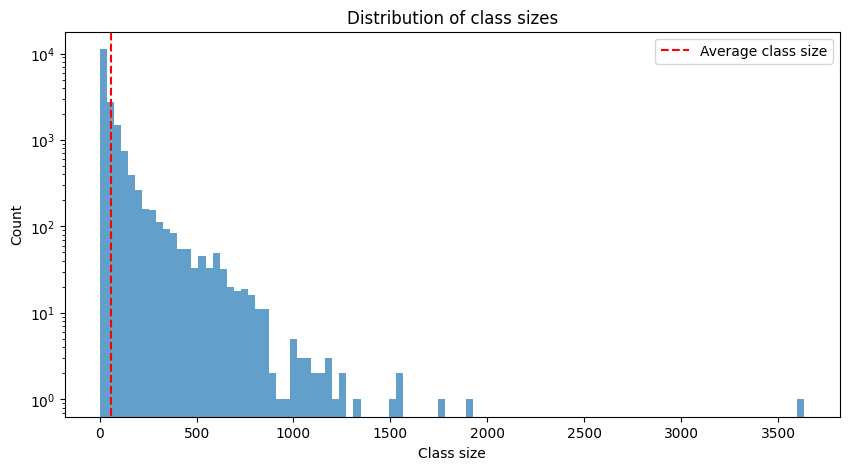

In [46]:
n_sequences = df.shape[0]
n_classes = df["accession_no"].nunique()
class_sizes = df.groupby("accession_no").size().values
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(class_sizes, bins=100, alpha=0.7)
ax.set(yscale='log')
ax.vlines(n_sequences / n_classes, 0, 1e5, color='red', linestyle='--', label='Average class size')
ax.legend()
ax.set_title("Distribution of class sizes")
ax.set_xlabel("Class size")
_ = ax.set_ylabel("Count")

We can see that the classes are very imbalanced, with the modal class size being 1 (516 occurunces), and the maximum class size being 3636. We will have to compensate for this when training our model and choose performance metrics carefully.
## Input Features

In [54]:
df["sequence_length"] = df["sequence"].apply(len)
df["sequence_length"].describe()

count    1.085997e+06
mean     1.554183e+02
std      1.201359e+02
min      4.000000e+00
25%      7.600000e+01
50%      1.190000e+02
75%      1.950000e+02
max      2.037000e+03
Name: sequence_length, dtype: float64

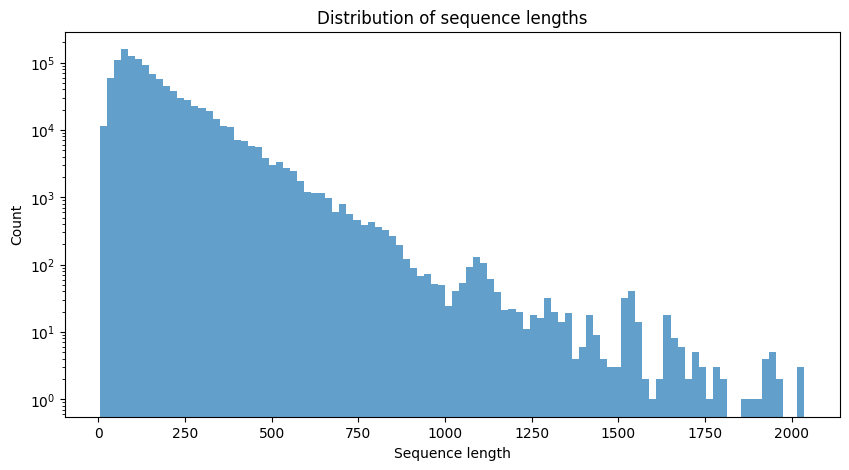

In [ ]:
sequences = df["sequence"].values
lengths = [len(seq) for seq in sequences]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(lengths, bins=100, alpha=0.7)
ax.set(yscale='log')
ax.set_title("Distribution of sequence lengths")
ax.set_xlabel("Sequence length")
_ = ax.set_ylabel("Count")

In [57]:
# get unique amino acids in the dataset and their counts
unique_amino_acids = Counter("".join(df["sequence"].values))


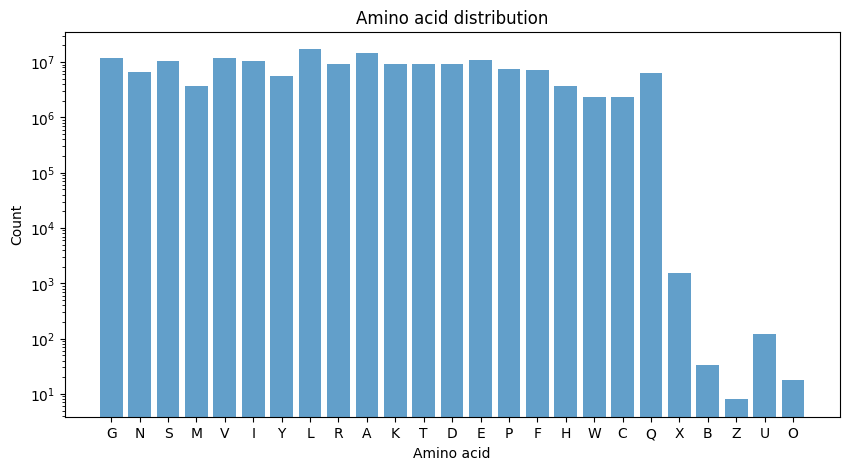

In [ ]:
# plot a bar chart of the unique amino acids and their counts sorted by count
keys, values = zip(*sorted(unique_amino_acids.items(), key=lambda x: x[1], reverse=True))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(keys, values, alpha=0.7)
ax.set_title("Amino acid distribution")
ax.set_xlabel("Amino acid")
ax.set_ylabel("Count")
_ = ax.set(yscale='log')

As discussed on the kaggle page, there are 20 frequently arising amino acids

Most likely, our input vector to our model will be a sequence of one hot vectors encoding each amino acid. 